In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [17]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=42)

In [18]:
X.shape

(1000, 2)

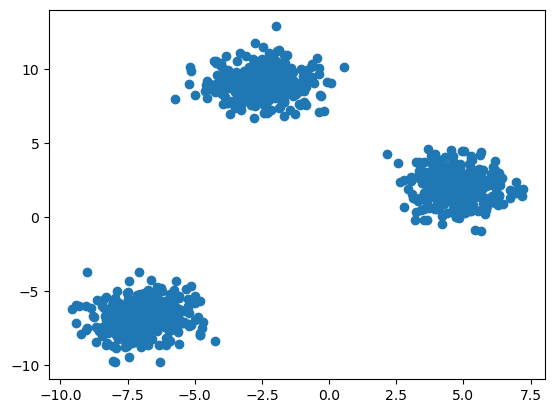

In [19]:
plt.scatter(X[:,0],X[:,1])

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [21]:
from sklearn.cluster import KMeans

In [22]:
## Manual process
## Elbow method to select the k value

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [23]:
wcss

[44450.72387542038,
 12741.823357662122,
 1329.7219815435358,
 1176.350844223127,
 1009.2849841537629,
 927.6630415713611,
 761.4566196261472,
 777.7531498916705,
 597.7725217464185,
 560.7116428684783]

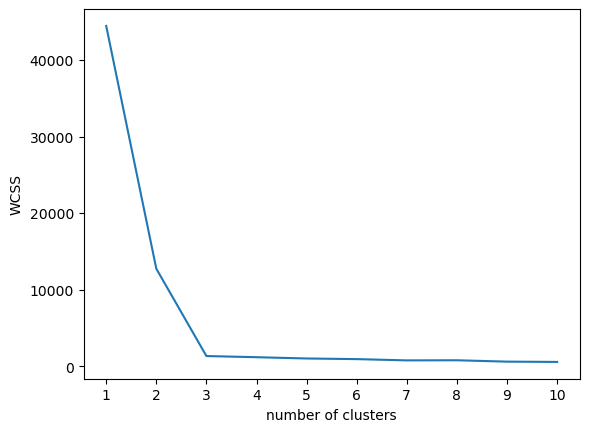

In [24]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [26]:
y_labels = kmeans.fit_predict(X_train)

In [27]:
y_test_label = kmeans.predict(X_test)

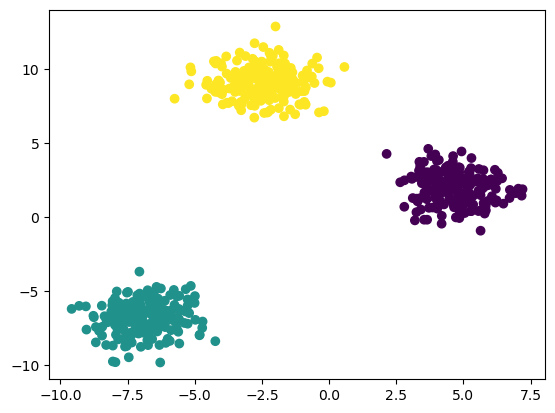

In [28]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

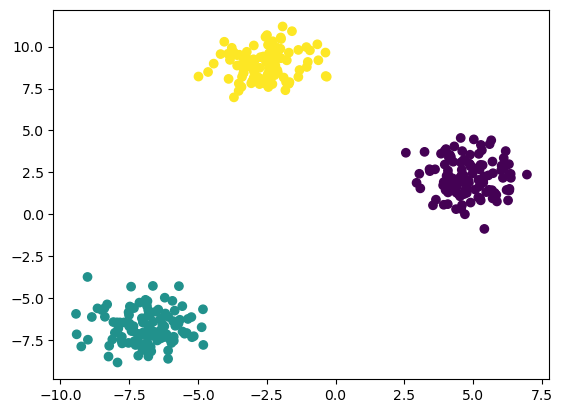

In [29]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)

In [15]:
## knee locator - a library in sklearn that finds k value automatic
%pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [30]:
from kneed import KneeLocator

In [32]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing') # curve in convex when going from up to down in graph
# and curve is concave when going from down to up in graph
kl.elbow

np.int64(3)

In [33]:
# performance metrics
# silhouette score
from sklearn.metrics import silhouette_score

In [34]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [35]:
silhouette_coefficients

[0.7024009416893275,
 0.8417121581954964,
 0.6587091700360512,
 0.4878817519544794,
 0.3372905645630259,
 0.33726806854396657,
 0.3394943964140945,
 0.31479590346439595,
 0.33140591680112946]

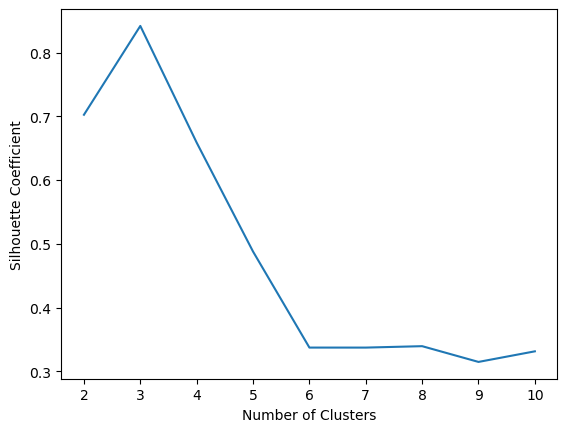

In [36]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()